# Data Science em Marketing

**Problema de Negócio**: Identificar grupos de clientes para campanhas de marketing personalizadas.

**Dataset**: Dados de comportamento de cerca de 9000 clientes de cartões de crédito durante 6 meses. Disponível em: https://www.kaggle.com/arjunbhasin2013/ccdata

Projeto estudado no treinamento "Ciência de Dados para Empresas e Negócios" de Jones Granatyr. Disponível em: https://www.udemy.com/course/ciencia-de-dados-para-empresas-e-negocios/

### Importação das bibliotecas


In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [85]:
# Carga do csv

dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DS_para_negocios/2-Marketing/Dataset_Marketing.csv')

In [86]:
# Visualização das primeras linhas

dataset.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Dicionário de Dados:**

CUSTID : Identification of Credit Card holder (Categorical)

BALANCE : Balance amount left in their account to make purchases (

BALANCEFREQUENCY : How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)

PURCHASES : Amount of purchases made from account

ONEOFFPURCHASES : Maximum purchase amount done in one-go

INSTALLMENTSPURCHASES : Amount of purchase done in installment

CASHADVANCE : Cash in advance given by the user

PURCHASESFREQUENCY : How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)

ONEOFFPURCHASESFREQUENCY : How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)

PURCHASESINSTALLMENTSFREQUENCY : How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)

CASHADVANCEFREQUENCY : How frequently the cash in advance being paid

CASHADVANCETRX : Number of Transactions made with "Cash in Advanced"

PURCHASESTRX : Numbe of purchase transactions made

CREDITLIMIT : Limit of Credit Card for user

PAYMENTS : Amount of Payment done by user

MINIMUM_PAYMENTS : Minimum amount of payments made by user

PRCFULLPAYMENT : Percent of full payment paid by user

TENURE : Tenure of credit card service for user

In [87]:
# Número de registros e colunas

dataset.shape

(8950, 18)

In [88]:
# Variáveis e tipos

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [89]:
# Estatísticas das variáveis numéricas

dataset.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


### Exploração dos Dados


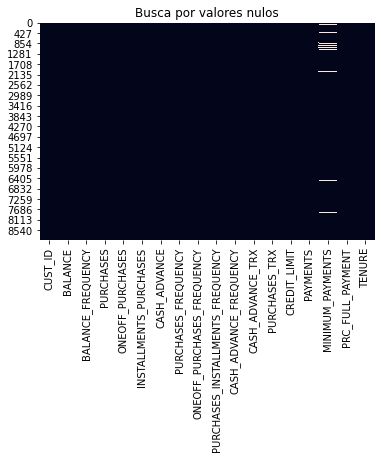

In [90]:
# Busca por valores nulos (valores nulos são indicados em branco)

sns.heatmap(dataset.isnull(), cbar=False)
plt.title('Busca por valores nulos')
plt.show()

In [91]:
# Contagem de valores nulos por variável

dataset.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [92]:
# Tratamento dos valores nulos (preenchimento com o valor médio)

dataset.loc[(dataset['MINIMUM_PAYMENTS'].isnull() == True), 'MINIMUM_PAYMENTS'] = dataset['MINIMUM_PAYMENTS'].mean()
dataset.loc[(dataset['CREDIT_LIMIT'].isnull() == True), 'CREDIT_LIMIT'] = dataset['CREDIT_LIMIT'].mean()

In [93]:
# Contagem de valores nulos por variável após o tratamento

dataset.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [94]:
# Eliminação do campo de identificação do cliente

dataset.drop('CUST_ID', axis=1, inplace=True)
dataset.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


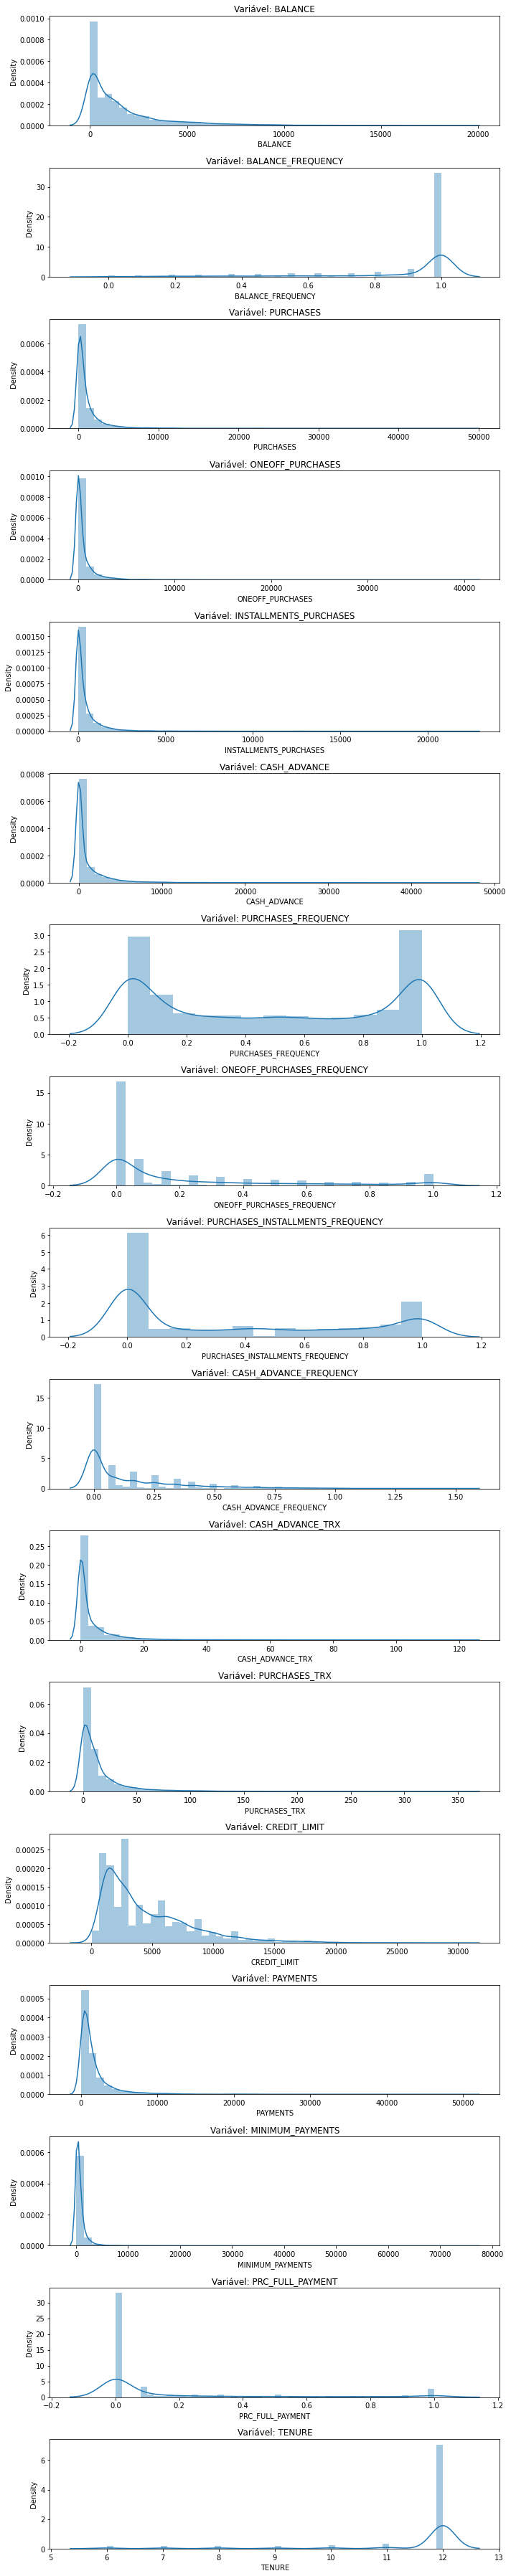

In [95]:
# Histograma de cada variável

plt.figure(figsize=(10,50))
for i in range(len(dataset.columns)):
  plt.subplot(len(dataset.columns), 1, i + 1)
  sns.distplot(dataset[dataset.columns[i]], kde = True)
  plt.title('Variável: ' + dataset.columns[i])
plt.tight_layout();

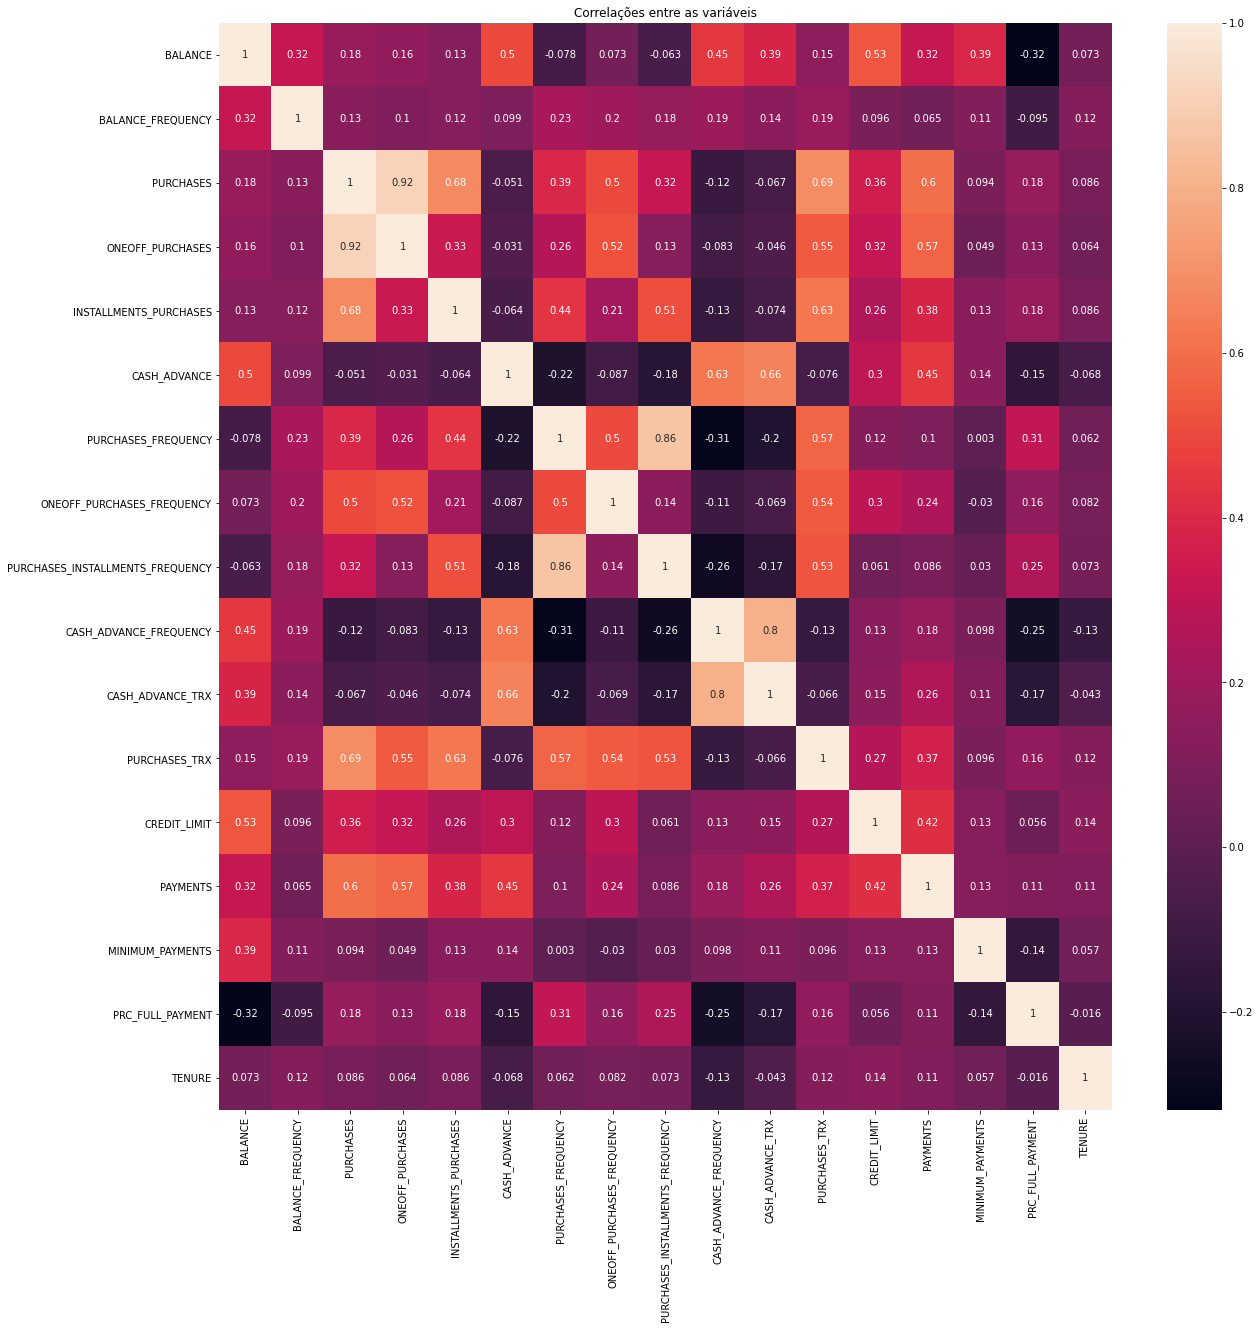

In [96]:
# Correlações entre as variáveis

correlacoes = dataset.corr()
f, ax = plt.subplots(figsize=(20,20))
sns.heatmap(correlacoes, annot=True )
plt.title('Correlações entre as variáveis')
plt.show()

### Definição do número ideal de clusters com Método de Elbow

In [97]:
# Padronização dos dados

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
dataset_padronizado = scaler.fit_transform(dataset)
dataset_padronizado

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.31096755,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.08931021,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.10166318,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.33546549,
         0.32919999, -4.12276757],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.34690648,
         0.32919999, -4.12276757],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.33294642,
        -0.52555097, -4.12276757]])

In [98]:
# Método de Elbow de 1 a 20 clusters
from sklearn.cluster import KMeans

wcss = []
for i in range(1,21):
  kmeans = KMeans(n_clusters=i)
  kmeans.fit(dataset_padronizado)
  wcss.append(kmeans.inertia_)

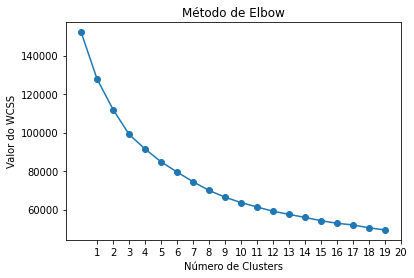

In [99]:
# Visualização do Método de Elbow

plt.plot(wcss, 'o-')
plt.xlabel('Número de Clusters')
plt.title('Método de Elbow')
plt.xticks(range(1,21))
plt.ylabel('Valor do WCSS')
plt.show()

### Agrupamento com KMeans (8 clusters)

In [100]:
# Construção do Modelo

kmeans = KMeans(n_clusters=8)

In [101]:
# Treinamento do Modelo

kmeans.fit(dataset_padronizado)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=8, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

In [102]:
# Armazenando o grupo de cada cliente

grupo = kmeans.labels_
grupo

array([3, 5, 0, ..., 2, 2, 2], dtype=int32)

In [103]:
# Dataframe com os centróides dos clusters

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids = pd.DataFrame(data=centroids, columns=[dataset.columns])
centroids

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,2112.434545,0.982487,3708.101950,2501.913170,1206.723063,388.896646,0.941577,0.764486,0.634885,0.059718,1.260018,52.485307,7715.449688,3537.510896,851.140305,0.299358,11.930543
1,104.025907,0.372947,351.746345,215.241115,136.754015,302.021403,0.272134,0.077503,0.187903,0.030832,0.682313,4.424141,3874.844463,1153.780482,263.496116,0.241373,11.788768
2,867.352424,0.795118,400.137016,251.249063,149.364143,1119.389302,0.412031,0.123046,0.272914,0.196395,3.238095,5.204762,2475.737221,606.497088,378.374934,0.155015,7.244444
3,1562.268352,0.972595,279.312221,231.766631,47.721453,735.580811,0.171334,0.110857,0.062409,0.148836,2.888770,3.280739,3384.671879,1014.435728,710.620927,0.021537,11.882374
4,5469.786878,0.958651,24597.057419,17745.470323,6851.587097,1798.881876,0.913441,0.765054,0.762366,0.080645,3.548387,145.903226,15535.483871,24909.448552,3377.529692,0.471041,11.935484
5,4930.419944,0.970476,528.978175,330.699967,198.390675,5114.153634,0.301255,0.143720,0.197473,0.518171,16.257743,8.241150,8105.812550,4032.751880,1688.483784,0.039594,11.619469
6,4281.378569,0.989028,1128.981724,223.876724,905.105000,1248.053614,0.478056,0.060867,0.431688,0.116379,3.534483,18.741379,4543.103448,1939.379640,22533.444215,0.001437,11.913793
7,768.340764,0.956357,933.361165,256.421447,677.346309,199.074644,0.881428,0.143094,0.796462,0.038902,0.758762,19.054620,3541.760344,1090.374463,586.422896,0.247094,11.857988


In [104]:
# Dataframe com identificação do cluster de cada cliente

dataset_cluster = pd.concat([dataset, pd.DataFrame(data=grupo, columns=['cluster'])], axis=1)
dataset_cluster

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,5
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,3
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,2
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,864.206542,0.000000,6,2
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,2
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,2


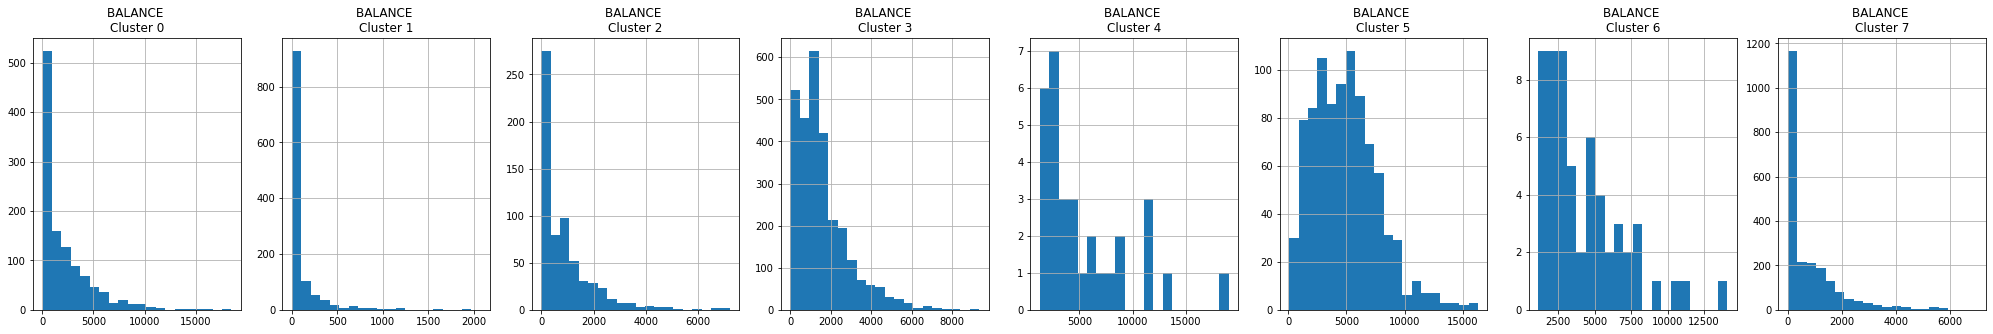

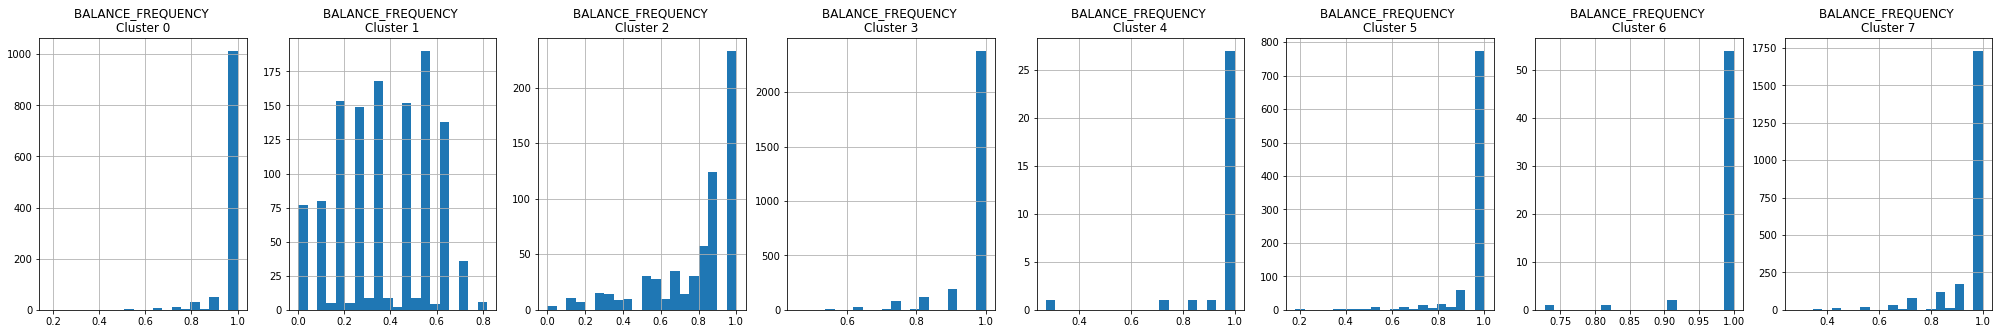

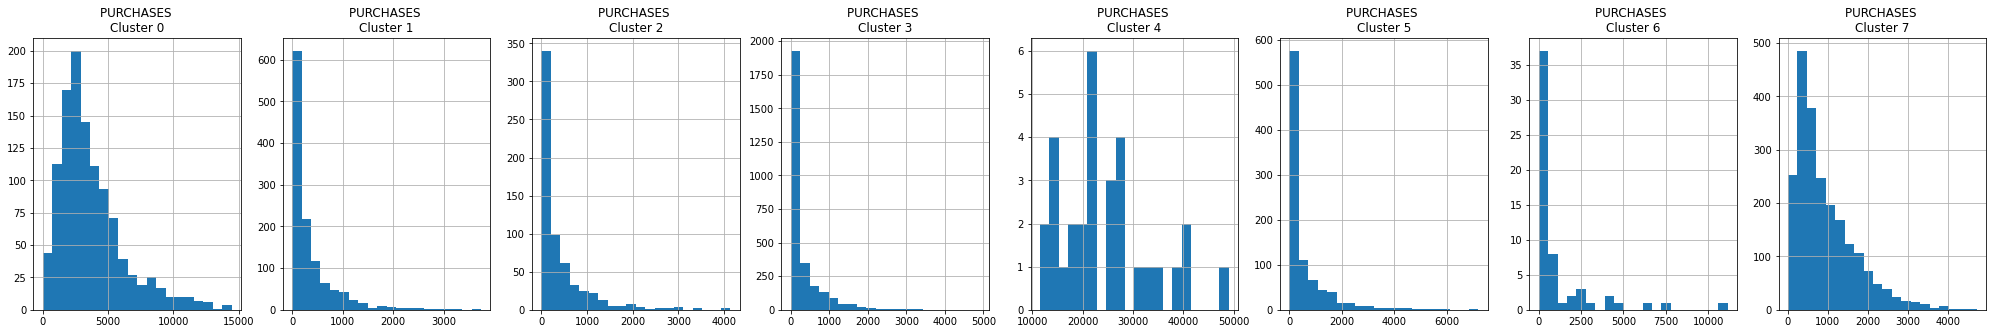

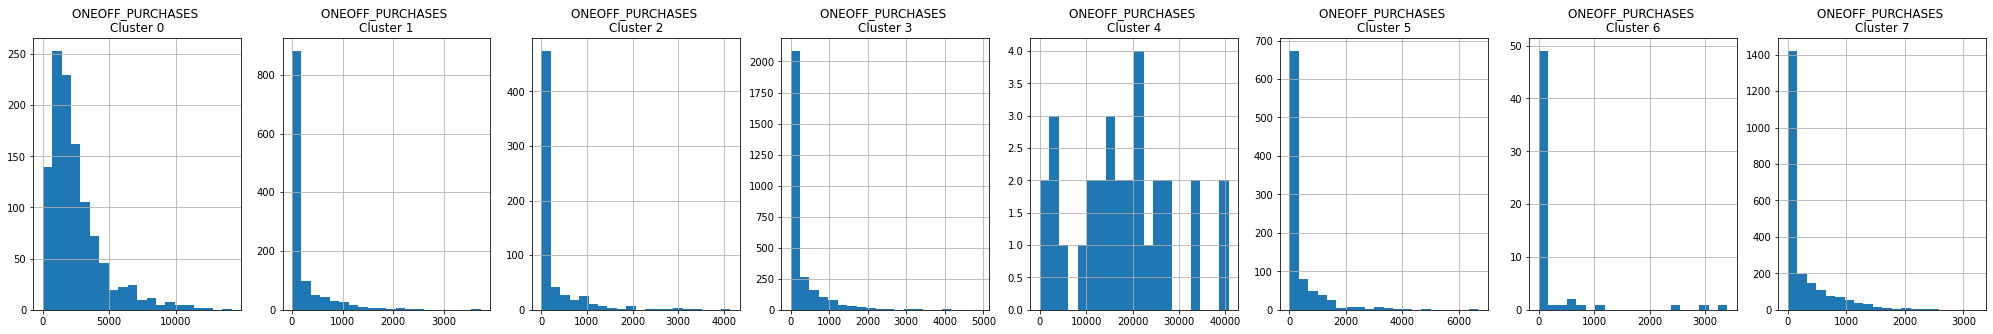

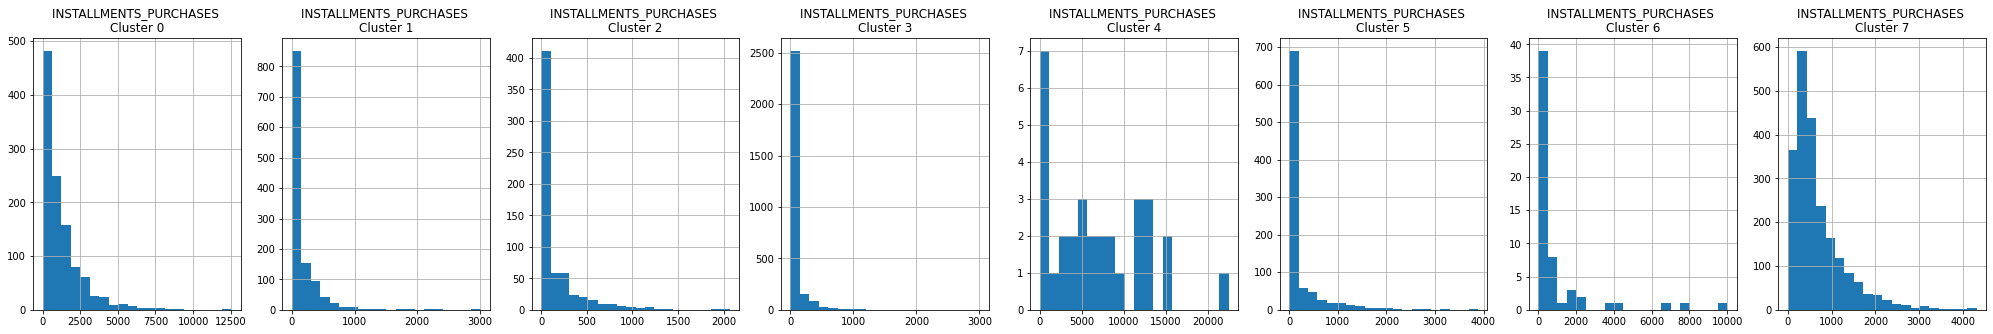

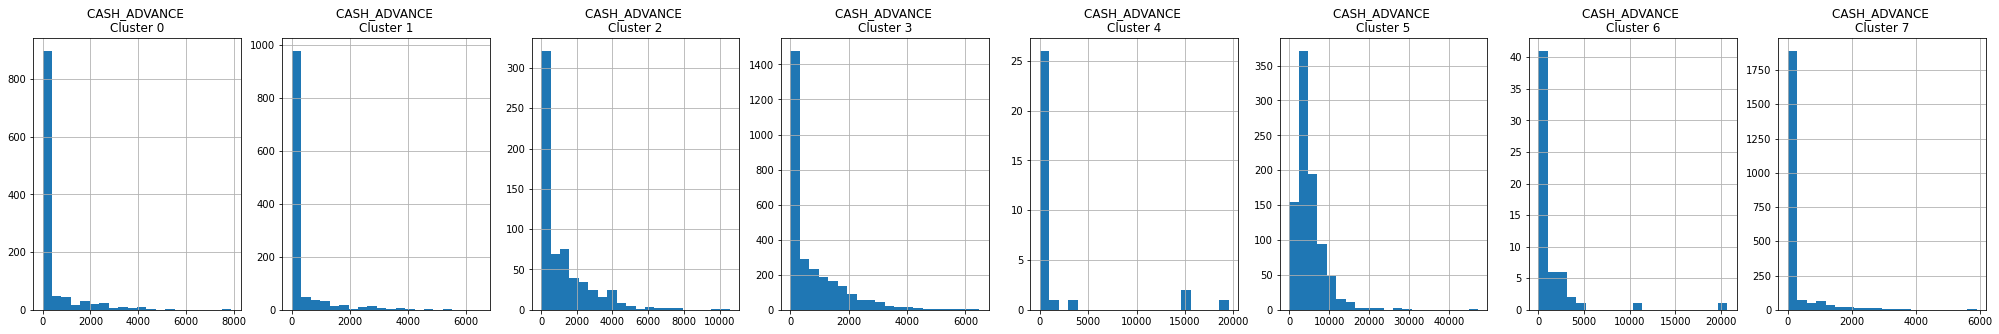

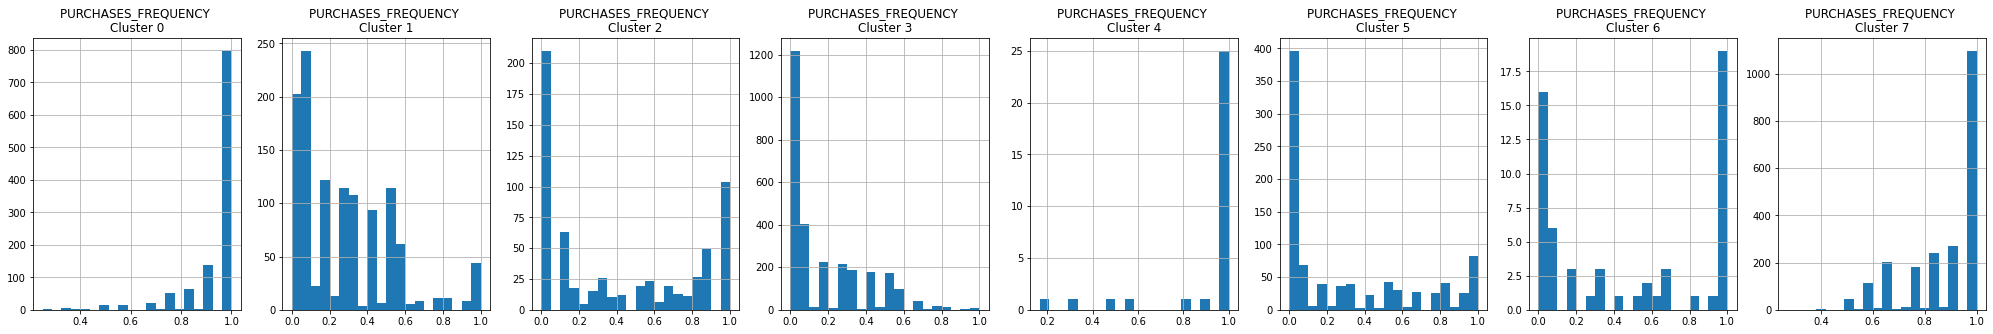

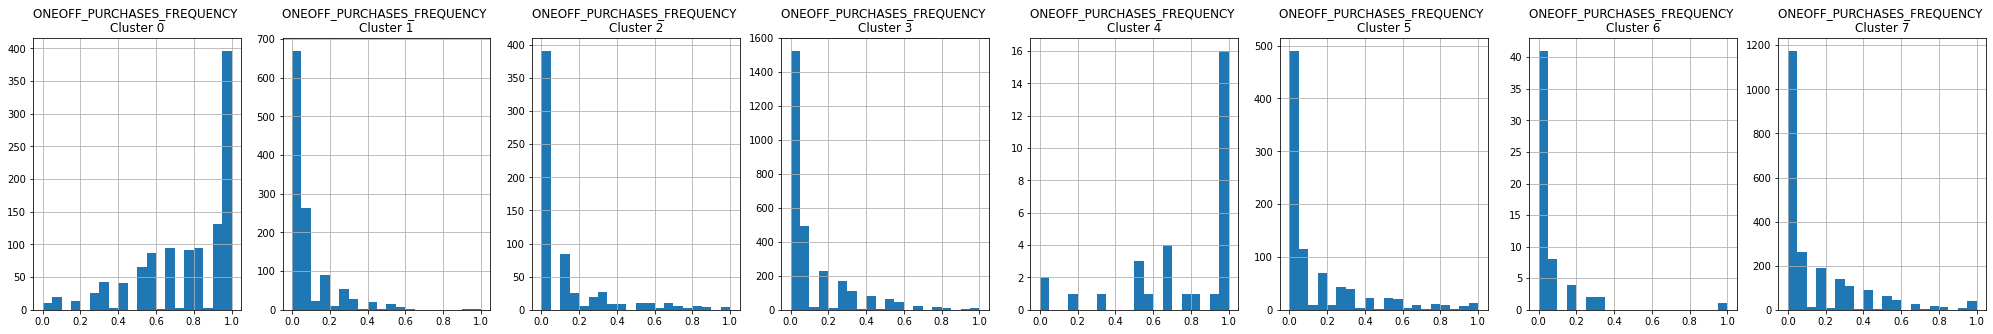

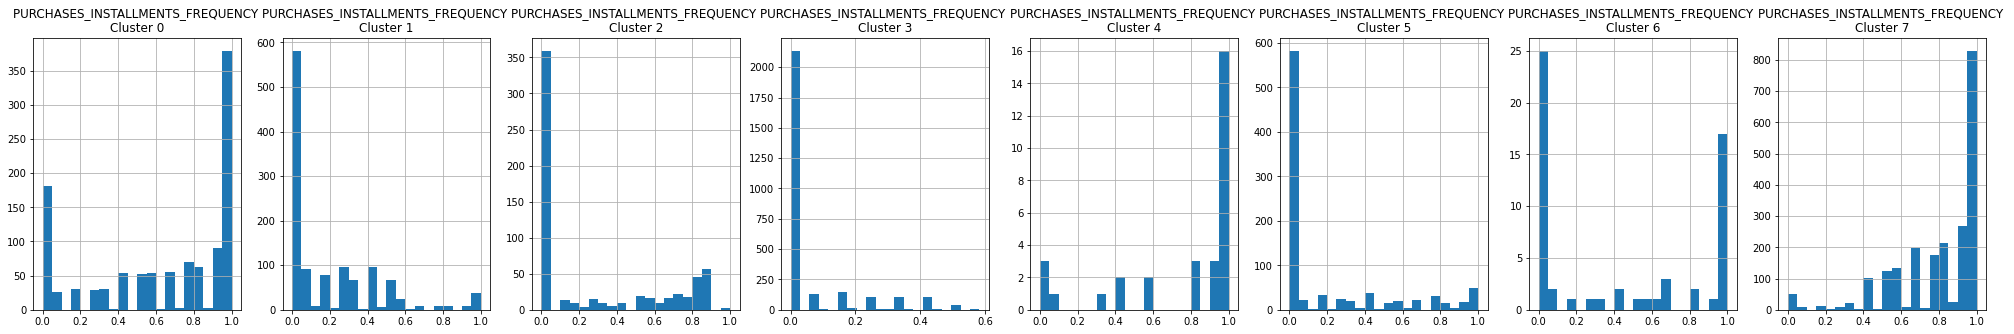

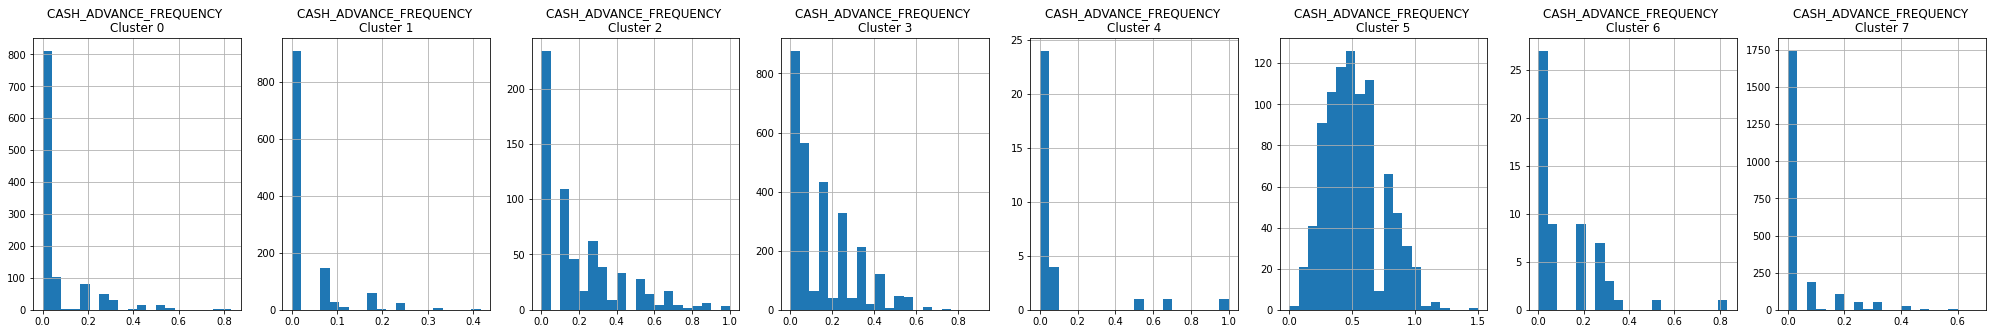

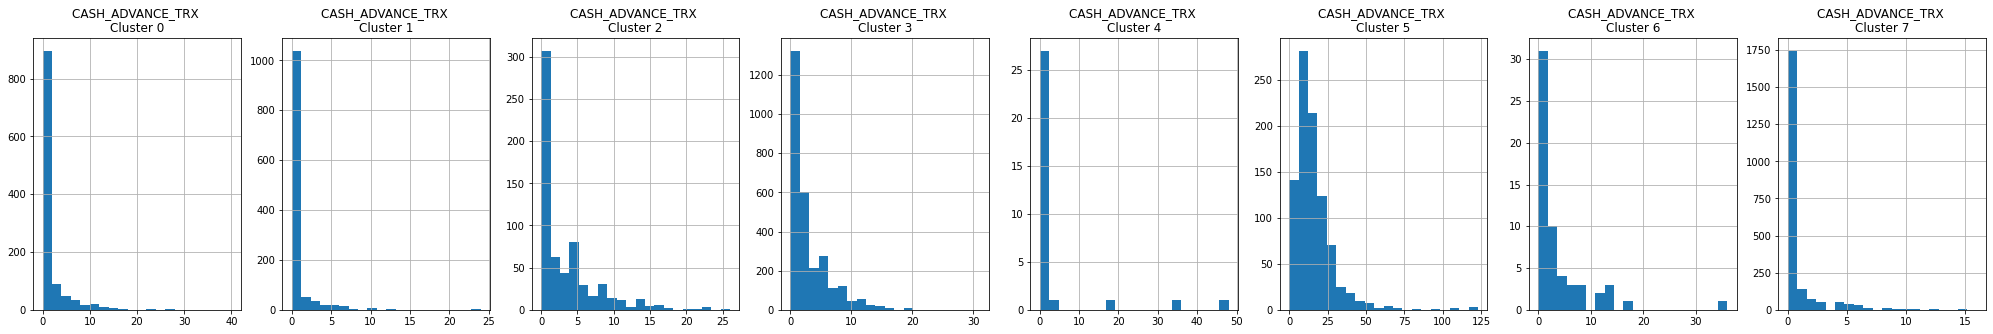

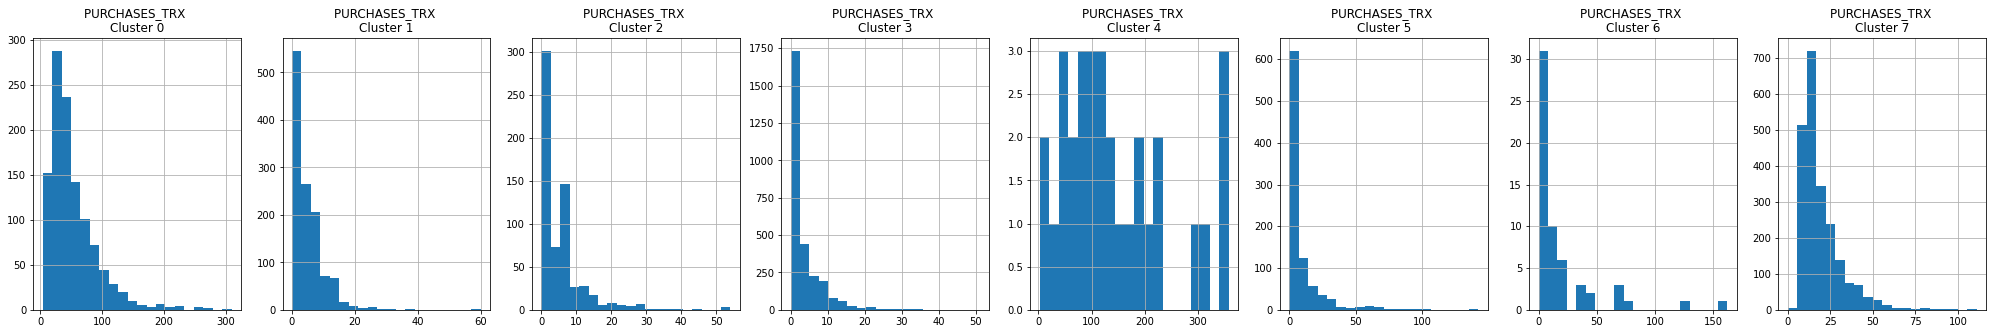

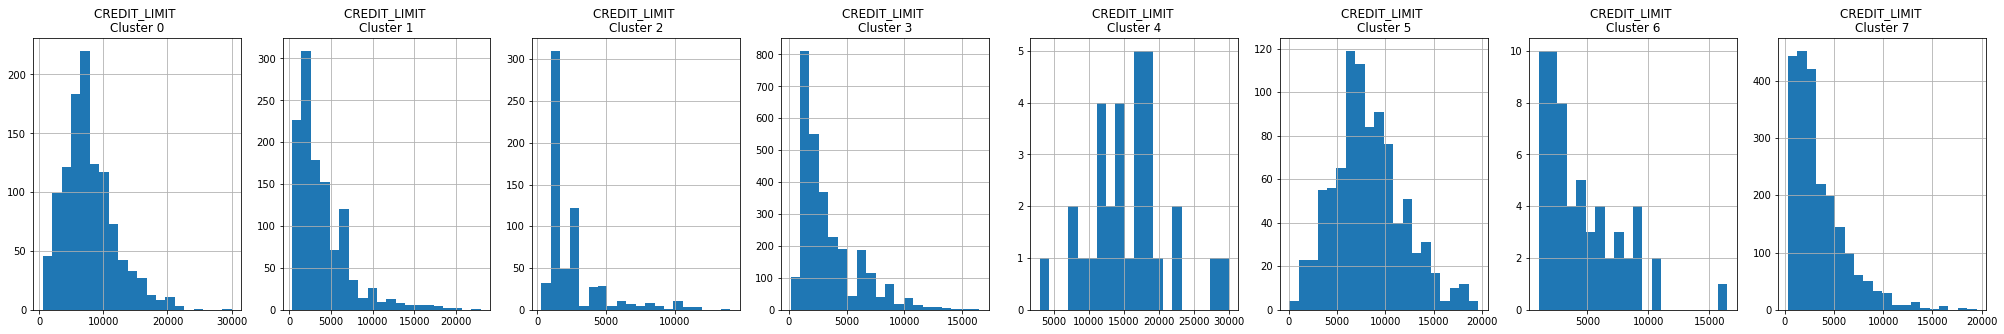

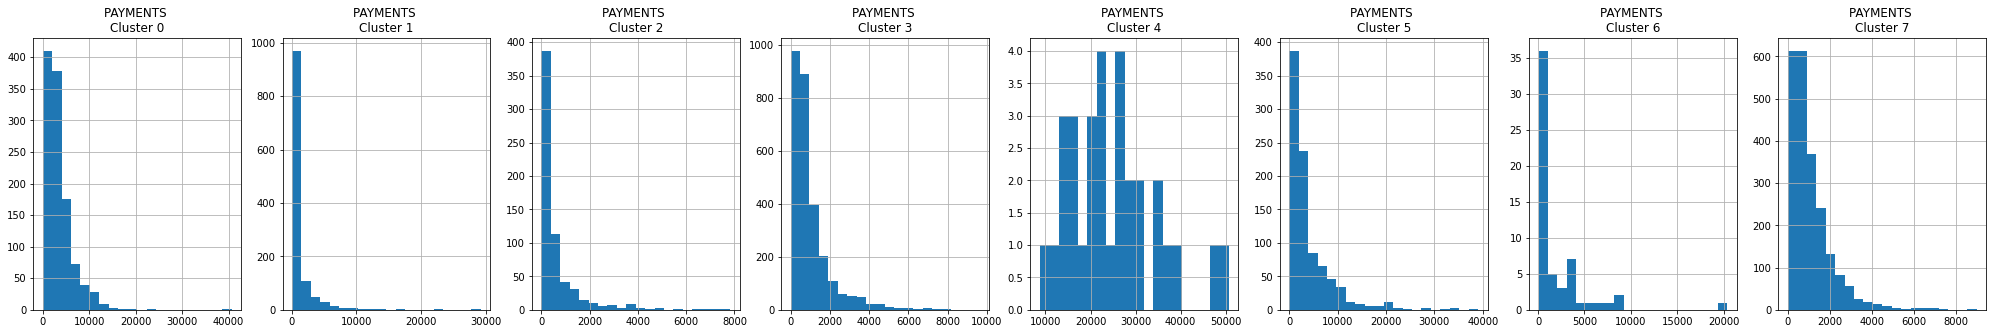

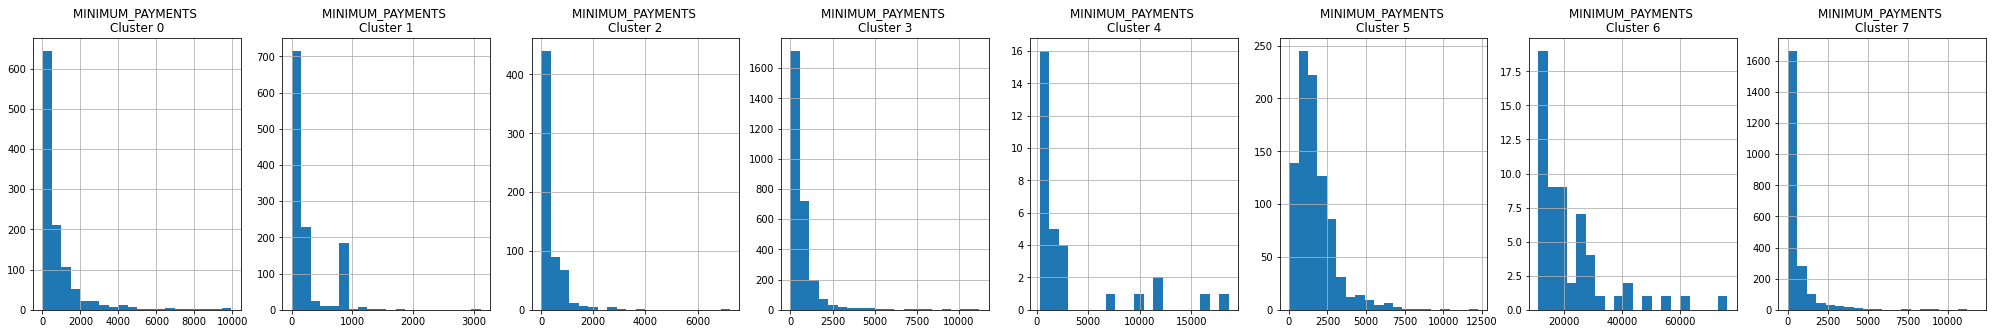

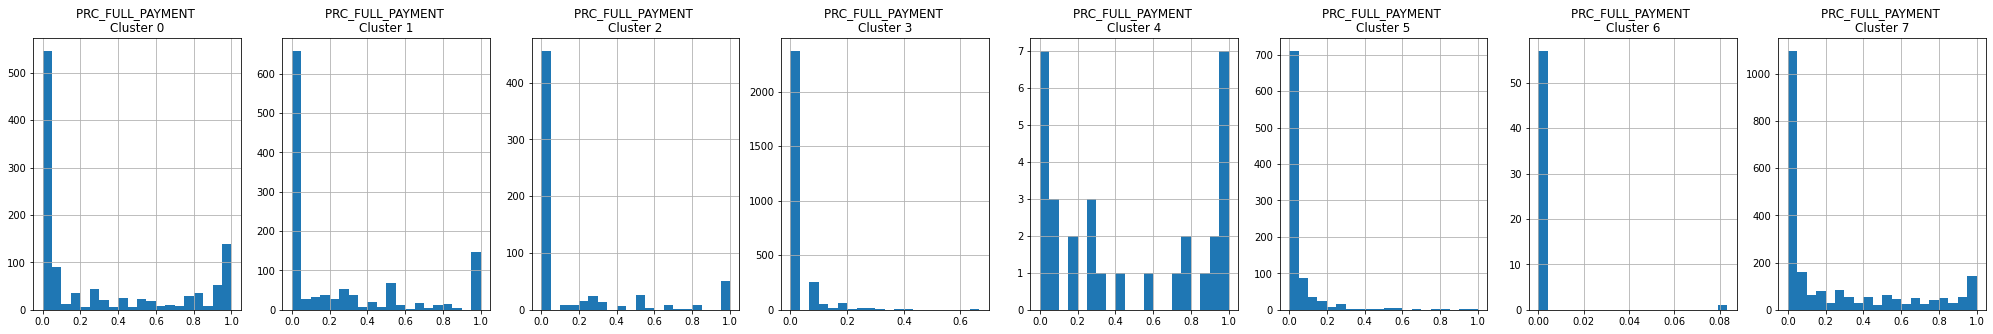

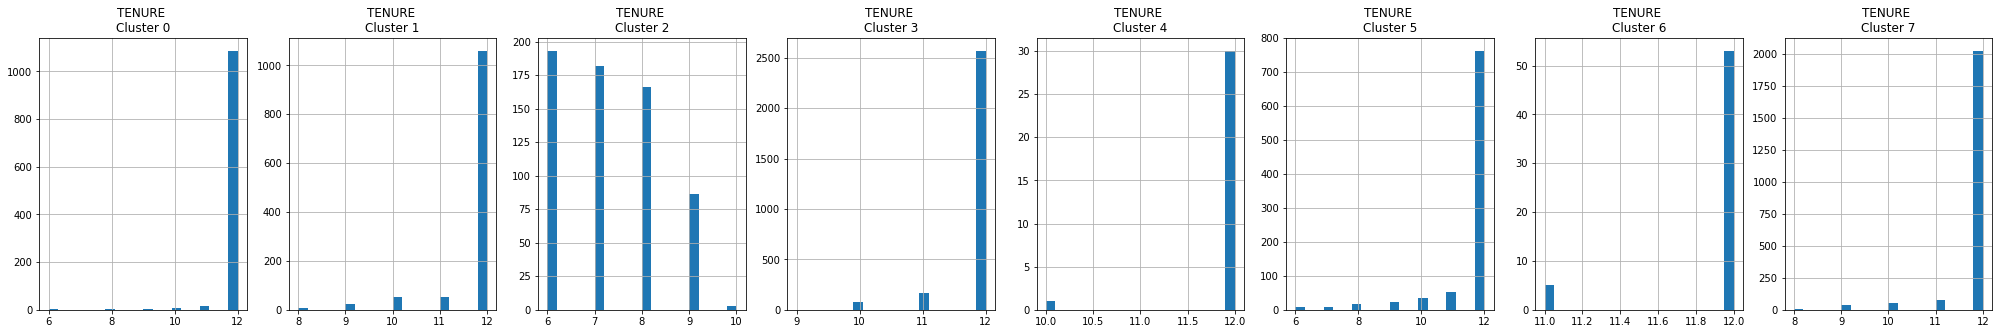

In [105]:
# Histograma para cada cluster/variável

for coluna in dataset.columns:
  plt.figure(figsize=(35,5))
  for cluster in range(kmeans.n_clusters):
    plt.subplot(1, kmeans.n_clusters, cluster + 1)
    n = dataset_cluster[dataset_cluster['cluster'] == cluster]
    n[coluna].hist(bins = 20)
    plt.title('{} \nCluster {}'.format(coluna, cluster))
  plt.show()


In [106]:
# Exportação dos dados por ordem de cluster

df_exportar = dataset_cluster.sort_values(by='cluster')
df_exportar

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
4356,4282.043906,1.000000,1974.04,1326.00,648.04,4310.515986,1.000000,1.000000,1.000000,0.5,14,40,7000.0,1920.094402,1942.567564,0.000000,12,0
7819,377.723728,1.000000,4587.21,4558.29,28.92,0.000000,1.000000,1.000000,0.083333,0.0,0,37,4500.0,4169.408064,185.710281,1.000000,12,0
2757,343.003474,1.000000,3429.49,2789.85,639.64,0.000000,1.000000,1.000000,0.666667,0.0,0,40,10500.0,2700.228732,211.715095,0.416667,12,0
2758,4360.245187,1.000000,703.23,703.23,0.00,0.000000,1.000000,1.000000,0.000000,0.0,0,12,4500.0,1372.421202,1377.096190,0.000000,12,0
2759,2900.668727,1.000000,3056.73,260.68,2796.05,0.000000,1.000000,0.250000,1.000000,0.0,0,54,10000.0,5402.934943,671.845831,0.000000,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3188,22.242824,1.000000,236.28,236.28,0.00,0.000000,0.833333,0.833333,0.000000,0.0,0,10,4000.0,258.457010,153.481269,0.545455,12,7
7262,26.864424,1.000000,373.77,0.00,373.77,0.000000,1.000000,0.000000,0.916667,0.0,0,12,7000.0,381.479704,160.260471,1.000000,12,7
1634,49.416158,0.727273,590.00,350.00,240.00,0.000000,0.583333,0.083333,0.500000,0.0,0,7,6000.0,836.812414,127.768461,1.000000,12,7
5560,1228.170181,1.000000,817.94,436.64,381.30,0.000000,0.666667,0.166667,0.500000,0.0,0,8,1500.0,708.383328,831.442071,0.000000,12,7


In [107]:
# Salvar em arquivo csv

df_exportar.to_csv('clientes_agrupados.csv')

# **O trabalho de clusterização está concluído e o arquivo csv pode ser enviado para a equipe de Marketing.**

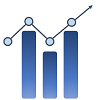 Outros projetos em https://thiagocmelods.github.io/


---